In [2]:
import pandas as pd
import glob
import os

# 配置路径
DATA_DIR = r"D:\Issue\2024_2025\code\data\processed"
OUTPUT_FILE = os.path.join(DATA_DIR, "CancerPPD_merged.csv")

# 匹配所有 CancerPPD_*.csv 文件
file_pattern = os.path.join(DATA_DIR, "CancerPPD_*.csv")
file_list = glob.glob(file_pattern)

if not file_list:
    print(f"未找到任何匹配的文件: {file_pattern}")
    exit()

print(f"找到 {len(file_list)} 个文件:")
for f in file_list:
    print(f"  - {os.path.basename(f)}")

# 逐个读取并提取所需列
df_list = []
for file in file_list:
    try:
        df_temp = pd.read_csv(file)
        # 检查必须的列是否存在
        if 'Sequence' not in df_temp.columns or 'Tissue Affected' not in df_temp.columns:
            print(f"警告: {os.path.basename(file)} 缺少 Sequence 或 Tissue Affected 列，跳过")
            continue
        # 只选择这两列
        df_temp = df_temp[['Sequence', 'Tissue Affected']]
        df_list.append(df_temp)
        print(f"已读取 {os.path.basename(file)}: {len(df_temp)} 行")
    except Exception as e:
        print(f"读取 {os.path.basename(file)} 时出错: {e}")

if not df_list:
    print("没有可合并的数据，退出")
    exit()

# 合并所有数据框
df_merged = pd.concat(df_list, ignore_index=True)
print(f"\n合并后总行数: {len(df_merged)}")

# 去除完全重复的行（可选）
df_merged.drop_duplicates(inplace=True)
print(f"去重后行数: {len(df_merged)}")

# 保存
df_merged.to_csv(OUTPUT_FILE, index=False)
print(f"合并后的文件已保存至: {OUTPUT_FILE}")

找到 9 个文件:
  - CancerPPD_blood.csv
  - CancerPPD_brain.csv
  - CancerPPD_breast.csv
  - CancerPPD_cervix.csv
  - CancerPPD_colon.csv
  - CancerPPD_liver.csv
  - CancerPPD_lung.csv
  - CancerPPD_prostate.csv
  - CancerPPD_skin.csv
已读取 CancerPPD_blood.csv: 536 行
已读取 CancerPPD_brain.csv: 202 行
已读取 CancerPPD_breast.csv: 981 行
已读取 CancerPPD_cervix.csv: 576 行
已读取 CancerPPD_colon.csv: 830 行
已读取 CancerPPD_liver.csv: 355 行
已读取 CancerPPD_lung.csv: 684 行
已读取 CancerPPD_prostate.csv: 367 行
已读取 CancerPPD_skin.csv: 680 行

合并后总行数: 5211
去重后行数: 3240
合并后的文件已保存至: D:\Issue\2024_2025\code\data\processed\CancerPPD_merged.csv


In [4]:
import pandas as pd

# 配置
INPUT_CSV = r"D:\Issue\2024_2025\code\data\processed\CancerPPD_merged.csv"
OUTPUT_CSV = r"D:\Issue\2024_2025\code\data\processed\CancerPPD_merged_filtered.csv"

# 标准氨基酸单字母（20种）
STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")

def is_standard_sequence(seq):
    """
    检查序列是否仅由标准20种氨基酸组成（忽略大小写，去除空格）
    """
    if pd.isna(seq):
        return False
    # 转为字符串、去除首尾空格、转为大写
    seq_clean = str(seq).strip().upper()
    if not seq_clean:  # 空字符串
        return False
    return all(ch in STANDARD_AA for ch in seq_clean)

def main():
    print(f"正在读取 {INPUT_CSV} ...")
    df = pd.read_csv(INPUT_CSV)
    print(f"原始行数: {len(df)}")

    if 'Sequence' not in df.columns:
        raise ValueError("CSV 文件中缺少 'Sequence' 列")

    # 应用过滤
    mask = df['Sequence'].apply(is_standard_sequence)
    df_filtered = df[mask].copy()

    # 将 Sequence 列转为大写（同时去除首尾空格）
    df_filtered['Sequence'] = df_filtered['Sequence'].astype(str).str.strip().str.upper()

    print(f"过滤后行数: {len(df_filtered)}")

    # 保存
    df_filtered.to_csv(OUTPUT_CSV, index=False)
    print(f"已保存至: {OUTPUT_CSV}")

    # 显示被删除的样例
    removed = df[~mask]
    if len(removed) > 0:
        print("\n被删除的序列示例（前5个）:")
        for seq in removed['Sequence'].head(5):
            print(f"  {seq}")

if __name__ == "__main__":
    main()

正在读取 D:\Issue\2024_2025\code\data\processed\CancerPPD_merged.csv ...
原始行数: 3240
过滤后行数: 2915
已保存至: D:\Issue\2024_2025\code\data\processed\CancerPPD_merged_filtered.csv

被删除的序列示例（前5个）:
  fCYwO-CyLeu-Pen-TKKrPKPfQwFwL-CyLeu-KKLMYPTYLKKfQWAV-Aib-HL
  Structure Given
  VN-Nal-KKLLGKLLKVVK
  VNWKK-Aib-LGK-Aib-IK-Aib-VK
  KNWKK-Aib-LKK-Aib-IK-Aib-VK


In [8]:
import pandas as pd

# 文件路径
FILE_PATH = r"D:\Issue\2024_2025\code\data\processed\CancerPPD_merged_filtered.csv"

# 读取 CSV
df = pd.read_csv(FILE_PATH)
print(f"原始行数: {len(df)}")

# 确保 Sequence 列为字符串类型
df['Sequence'] = df['Sequence'].astype(str)

# 计算长度并过滤（仅保留长度 <= 50 的序列）
df['seq_len'] = df['Sequence'].str.len()
df_filtered = df[df['seq_len'] <= 50].drop(columns=['seq_len'])

print(f"过滤后行数: {len(df_filtered)}")

# 覆盖原文件
df_filtered.to_csv(FILE_PATH, index=False)
print(f"已更新文件: {FILE_PATH}")

原始行数: 2915
过滤后行数: 2886
已更新文件: D:\Issue\2024_2025\code\data\processed\CancerPPD_merged_filtered.csv


In [9]:
import pandas as pd
import os

# 配置
INPUT_CSV = r"D:\Issue\2024_2025\code\data\processed\CancerPPD_merged_filtered.csv"
OUTPUT_TXT = r"D:\Issue\2024_2025\code\data\processed\prefix_training_data.txt"
# 多标签分隔符（若存在）
SEPARATORS = [';', ',']  # 支持分号和逗号，可根据实际情况调整

def split_cancers(cancer_str):
    """将癌症字符串按常见分隔符拆分成列表，并去除空白"""
    if pd.isna(cancer_str):
        return []
    cancer_str = str(cancer_str)
    # 先尝试按指定分隔符拆分
    for sep in SEPARATORS:
        if sep in cancer_str:
            parts = [p.strip() for p in cancer_str.split(sep) if p.strip()]
            return parts
    # 若无分隔符，则整体返回
    return [cancer_str.strip()]

def main():
    print(f"读取 {INPUT_CSV} ...")
    df = pd.read_csv(INPUT_CSV)
    print(f"共有 {len(df)} 行")

    # 检查必要列
    if 'Sequence' not in df.columns or 'Tissue Affected' not in df.columns:
        raise ValueError("CSV 中缺少 'Sequence' 或 'Tissue Affected' 列")

    # 过滤空序列
    df = df.dropna(subset=['Sequence'])
    df['Sequence'] = df['Sequence'].astype(str).str.strip()
    df = df[df['Sequence'] != '']

    total_lines = 0
    with open(OUTPUT_TXT, 'w', encoding='utf-8') as f:
        for _, row in df.iterrows():
            seq = row['Sequence']
            cancers = split_cancers(row['Tissue Affected'])
            if not cancers:
                continue
            for cancer in cancers:
                # 去除前缀中可能存在的多余空格，并确保格式 [cancer] sequence
                f.write(f"[{cancer}] {seq}\n")
                total_lines += 1

    print(f"已写入 {total_lines} 条记录到 {OUTPUT_TXT}")

if __name__ == "__main__":
    main()

读取 D:\Issue\2024_2025\code\data\processed\CancerPPD_merged_filtered.csv ...
共有 2886 行
已写入 2886 条记录到 D:\Issue\2024_2025\code\data\processed\prefix_training_data.txt


In [10]:
import pandas as pd
import json
import os

# 文件路径
CSV_PATH = r"D:\Issue\2024_2025\code\data\processed\CancerPPD_merged_filtered.csv"
OUTPUT_JSON = r"D:\Issue\2024_2025\code\data\processed\cancer_to_idx.json"

# 读取 CSV
df = pd.read_csv(CSV_PATH)

# 提取 Tissue Affected 列
tissue_series = df['Tissue Affected'].dropna()

# 拆分为多标签列表
cancer_set = set()
for text in tissue_series:
    # 按分号或逗号拆分
    for sep in [';', ',']:
        if sep in text:
            parts = [p.strip() for p in text.split(sep) if p.strip()]
            cancer_set.update(parts)
            break
    else:
        # 无分隔符
        cancer_set.add(text.strip())

# 排序生成字典
cancer_list = sorted(cancer_set)
cancer_to_idx = {c: i for i, c in enumerate(cancer_list)}

# 保存为 JSON
with open(OUTPUT_JSON, 'w') as f:
    json.dump(cancer_to_idx, f, indent=4)

print(f"共 {len(cancer_to_idx)} 种癌症类型，已保存至 {OUTPUT_JSON}")

共 9 种癌症类型，已保存至 D:\Issue\2024_2025\code\data\processed\cancer_to_idx.json


In [2]:
import os
os.chdir("D:/Issue/2024_2025/PGD-Diff")

In [3]:
#条件数据信号增强
import os
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
from tqdm import tqdm

# ==================== 配置 ====================
INPUT_FILE = "data/processed/prefix_training_data.txt"                # 原始文件（或已去重后的文件）
OUTPUT_FILE = "data/processed/prefix_training_data_clean.txt"         # 清洗后的输出文件
ESM2_MODEL_PATH = "E:/huggingface/esm2_t6_8M_UR50D"   # 你的ESM2路径
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ========== 筛选参数（可调） ==========
RETAIN_RATIO = 0.85  # 保留每个癌种中距离质心最近的前 85%（剔除最远的 15%）

print(f"使用设备: {DEVICE}")

# ==================== 1. 读取数据 ====================
print("📖 读取数据...")
seqs_by_label = defaultdict(list)
raw_lines_by_label = defaultdict(list)

with open(INPUT_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        start = line.find('[')
        end = line.find(']')
        if start == -1 or end == -1:
            continue
        label_str = line[start+1:end].strip()
        seq = line[end+1:].strip().upper()
        if not seq or not label_str:
            continue
        labels = [l.strip() for l in label_str.split(',') if l.strip()]
        for lab in labels:
            seqs_by_label[lab].append(seq)
            raw_lines_by_label[lab].append(line)

print(f"原始标签类别数: {len(seqs_by_label.keys())}")
total_raw = sum(len(v) for v in seqs_by_label.values())
print(f"总样本数: {total_raw}")

# ==================== 2. ESM2 编码 ====================
def get_esm2_embeddings(sequences, batch_size=64):
    tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_PATH, local_files_only=True)
    model = AutoModel.from_pretrained(ESM2_MODEL_PATH, local_files_only=True).to(DEVICE)
    model.eval()
    
    embeddings = []
    for i in tqdm(range(0, len(sequences), batch_size), desc="ESM2 Encoding"):
        batch = sequences[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=50)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        embeddings.append(emb)
    return np.vstack(embeddings)

print("🧬 编码所有序列...")
all_seqs = []
all_labels = []
for lab, seqs in seqs_by_label.items():
    all_seqs.extend(seqs)
    all_labels.extend([lab] * len(seqs))

embeddings = get_esm2_embeddings(all_seqs, batch_size=64)
print(f"嵌入矩阵形状: {embeddings.shape}")

# ==================== 3. 计算质心与距离 ====================
print("📊 计算聚类质心和距离...")

scaler = StandardScaler()
emb_scaled = scaler.fit_transform(embeddings)

# 获取唯一标签
unique_labels = list(seqs_by_label.keys())

# 构建索引映射（转换为 numpy 数组以便于布尔索引）
label_to_indices = {}
for lab in unique_labels:
    # 获取该标签对应的所有索引（list -> numpy array）
    indices = [i for i, l in enumerate(all_labels) if l == lab]
    label_to_indices[lab] = np.array(indices)

# 计算每个类别的质心
centroids = {}
for lab, indices in label_to_indices.items():
    centroids[lab] = np.mean(emb_scaled[indices], axis=0)

# 计算每个序列的指标
dist_to_own = np.zeros(len(emb_scaled))
dist_to_nearest_other = np.full(len(emb_scaled), np.inf)

for lab, indices in label_to_indices.items():
    centroid = centroids[lab]
    class_embs = emb_scaled[indices]
    # 到本类质心的距离
    own_dists = np.linalg.norm(class_embs - centroid, axis=1)
    dist_to_own[indices] = own_dists
    
    # 到最近其他类质心的距离
    other_centroids = [centroids[other] for other in unique_labels if other != lab]
    if other_centroids:
        other_centroids_matrix = np.array(other_centroids)
        # 对每个样本计算到所有其他质心的距离，取最小值
        for i, idx in enumerate(indices):
            sample = class_embs[i]
            min_dist = np.min(np.linalg.norm(sample - other_centroids_matrix, axis=1))
            dist_to_nearest_other[idx] = min_dist

# ==================== 4. 筛选逻辑 ====================
print("🔍 执行筛选...")
keep_indices = []

for lab, indices in label_to_indices.items():
    own_dists = dist_to_own[indices]
    other_dists = dist_to_nearest_other[indices]
    
    # 策略 A：剔除边界点（离自己远，离别人近）
    boundary_mask = own_dists < other_dists  # 布尔数组，长度与 indices 相同
    candidate_indices = indices[boundary_mask]  # 现在 indices 是 np.array，支持布尔索引
    
    if len(candidate_indices) == 0:
        continue
        
    # 策略 B：保留距离质心最近的前 RETAIN_RATIO 样本
    candidate_own_dists = dist_to_own[candidate_indices]
    sorted_idx = np.argsort(candidate_own_dists)
    keep_num = max(1, int(len(sorted_idx) * RETAIN_RATIO))
    keep_candidates = candidate_indices[sorted_idx[:keep_num]]
    keep_indices.extend(keep_candidates)

keep_indices = sorted(keep_indices)
print(f"原始总样本: {len(emb_scaled)}")
print(f"清洗后保留: {len(keep_indices)}")
print(f"剔除数量: {len(emb_scaled) - len(keep_indices)}")

# ==================== 5. 输出新文件 ====================
print("💾 写入清洗后的文件...")
# 构建 idx_to_line 映射
idx_to_line = []
for lab in unique_labels:
    lines = raw_lines_by_label[lab]
    seqs = seqs_by_label[lab]
    # 确保顺序一致（理论上读取顺序一致）
    # 但为了安全，用 seq 匹配
    # 更可靠：直接用 seq 匹配 line
    seq_to_line = {}
    for line in lines:
        s = line[line.find(']')+1:].strip().upper()
        seq_to_line[s] = line
    for seq in seqs:
        idx_to_line.append(seq_to_line.get(seq, f"[{lab}] {seq}"))  # 如果没匹配到，构造一个

# 如果因为多标签拆分导致长度不一致，用 all_seqs 重建
if len(idx_to_line) != len(all_seqs):
    print("长度不匹配，使用 all_seqs 重建 idx_to_line...")
    seq_to_line_global = {}
    for lab in unique_labels:
        for line in raw_lines_by_label[lab]:
            s = line[line.find(']')+1:].strip().upper()
            seq_to_line_global[s] = line
    idx_to_line = [seq_to_line_global.get(seq, f"[unknown] {seq}") for seq in all_seqs]

# 写入保留的行
with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
    for idx in keep_indices:
        f.write(idx_to_line[idx] + '\n')

print(f"✅ 清洗完成！新文件已保存为: {OUTPUT_FILE}")

# ==================== 6. 统计输出 ====================
print("\n📊 各标签保留情况统计:")
for lab in unique_labels:
    original_count = len(seqs_by_label[lab])
    kept_count = sum(1 for idx in keep_indices if all_labels[idx] == lab)
    print(f"  {lab}: 原始 {original_count} 条 -> 保留 {kept_count} 条 (剔除 {original_count - kept_count} 条)")

使用设备: cuda
📖 读取数据...
原始标签类别数: 9
总样本数: 2886
🧬 编码所有序列...


Some weights of EsmModel were not initialized from the model checkpoint at E:/huggingface/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
ESM2 Encoding:   0%|          | 0/46 [00:00<?, ?it/s]d:\anaconda\envs\mmcd\lib\site-packages\transformers\integrations\sdpa_attention.py:96: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
ESM2 Encoding: 100%|██████████| 46/46 [00:01<00:00, 26.19it/s]


嵌入矩阵形状: (2886, 320)
📊 计算聚类质心和距离...
🔍 执行筛选...
原始总样本: 2886
清洗后保留: 432
剔除数量: 2454
💾 写入清洗后的文件...
✅ 清洗完成！新文件已保存为: data/processed/prefix_training_data_clean.txt

📊 各标签保留情况统计:
  Blood: 原始 244 条 -> 保留 93 条 (剔除 151 条)
  Brain: 原始 116 条 -> 保留 51 条 (剔除 65 条)
  Breast: 原始 555 条 -> 保留 32 条 (剔除 523 条)
  Cervix: 原始 359 条 -> 保留 32 条 (剔除 327 条)
  Colon: 原始 412 条 -> 保留 5 条 (剔除 407 条)
  Liver: 原始 167 条 -> 保留 71 条 (剔除 96 条)
  Lung: 原始 437 条 -> 保留 31 条 (剔除 406 条)
  Prostate: 原始 288 条 -> 保留 62 条 (剔除 226 条)
  Skin: 原始 308 条 -> 保留 55 条 (剔除 253 条)


In [6]:
import os
from collections import defaultdict

def filter_multilabel(input_path, output_path):
    # 第一遍：构建序列到标签集合的映射，并保存所有行
    seq_to_labels = defaultdict(set)
    lines = []  # 存储 (seq, line) 元组
    with open(input_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            start = line.find('[')
            end = line.find(']')
            if start == -1 or end == -1:
                continue
            label_str = line[start+1:end].strip()
            seq = line[end+1:].strip().upper()
            if not seq or not label_str:
                continue
            labels = [l.strip() for l in label_str.split(',') if l.strip()]
            for lab in labels:
                seq_to_labels[seq].add(lab)
            lines.append((seq, line))
    
    # 找出所有多标签序列（标签集合大小 > 1）
    multi_label_seqs = {seq for seq, labs in seq_to_labels.items() if len(labs) > 1}
    
    print(f"总唯一序列数: {len(seq_to_labels)}")
    print(f"多标签序列数: {len(multi_label_seqs)}")
    
    # 第二遍：写入新文件，跳过含有多标签序列的行
    kept = 0
    removed = 0
    with open(output_path, 'w', encoding='utf-8') as out:
        for seq, line in lines:
            if seq in multi_label_seqs:
                removed += 1
                continue
            out.write(line + '\n')
            kept += 1
    
    print(f"保留行数: {kept}, 删除行数: {removed}")
    print(f"✅ 新文件已保存至: {output_path}")

if __name__ == "__main__":
    input_file = "data/processed/prefix_training_data_clean.txt"
    output_file = "data/processed/prefix_training_data_clean_single_label.txt"
    if os.path.exists(input_file):
        filter_multilabel(input_file, output_file)
    else:
        print(f"❌ 文件 {input_file} 不存在，请检查路径。")

总唯一序列数: 401
多标签序列数: 6
保留行数: 419, 删除行数: 13
✅ 新文件已保存至: data/processed/prefix_training_data_clean_single_label.txt


In [ ]:
#筛除序列长度小于5
import os
from collections import Counter

def filter_by_length(input_path, output_path, min_length=5):
    """
    读取文件，保留序列长度 >= min_length 的行。
    同时统计各标签的原始/保留数量。
    """
    kept_lines = []
    removed_lines = []
    label_counts_original = Counter()
    label_counts_kept = Counter()

    with open(input_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            start = line.find('[')
            end = line.find(']')
            if start == -1 or end == -1:
                continue
            label_str = line[start+1:end].strip()
            seq = line[end+1:].strip().upper()
            if not seq or not label_str:
                continue
            # 解析标签（单标签，但万一有逗号就拆分统计）
            labels = [l.strip() for l in label_str.split(',') if l.strip()]
            # 对于统计，我们按每个标签计数（如果一行有多个标签，会重复计入，但你的数据应该是单标签）
            for lab in labels:
                label_counts_original[lab] += 1

            # 判断序列长度
            if len(seq) >= min_length:
                kept_lines.append(line)
                for lab in labels:
                    label_counts_kept[lab] += 1
            else:
                removed_lines.append(line)

    # 写入输出文件
    with open(output_path, 'w', encoding='utf-8') as f:
        for line in kept_lines:
            f.write(line + '\n')

    # 打印统计信息
    print(f"原始总行数: {len(kept_lines) + len(removed_lines)}")
    print(f"保留行数: {len(kept_lines)} (序列长度 ≥ {min_length})")
    print(f"删除行数: {len(removed_lines)} (序列长度 < {min_length})")
    print("\n各标签原始样本数:")
    for lab, cnt in sorted(label_counts_original.items(), key=lambda x: -x[1]):
        print(f"  {lab}: {cnt}")
    print("\n各标签保留样本数:")
    for lab, cnt in sorted(label_counts_kept.items(), key=lambda x: -x[1]):
        print(f"  {lab}: {cnt}")
    print(f"\n✅ 过滤后的文件已保存至: {output_path}")

if __name__ == "__main__":
    input_file = "data/processed/prefix_training_data_clean_single_label.txt"
    output_file = "data/processed/prefix_training_data_final.txt"
    if os.path.exists(input_file):
        filter_by_length(input_file, output_file, min_length=5)
    else:
        print(f"❌ 文件 {input_file} 不存在，请检查路径。")

原始总行数: 416
保留行数: 405 (序列长度 ≥ 5)
删除行数: 11 (序列长度 < 5)

各标签原始样本数:
  Blood: 92
  Liver: 71
  Prostate: 59
  Skin: 54
  Brain: 50
  Breast: 32
  Cervix: 31
  Lung: 27

各标签保留样本数:
  Blood: 92
  Liver: 60
  Prostate: 59
  Skin: 54
  Brain: 50
  Breast: 32
  Cervix: 31
  Lung: 27

✅ 过滤后的文件已保存至: data/processed/prefix_training_data_filtered_length5.txt


Some weights of EsmModel were not initialized from the model checkpoint at E:/huggingface/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


使用设备: cuda
📖 读取数据...
共找到 405 条序列
各标签样本数:
  Blood: 92
  Liver: 60
  Prostate: 59
  Skin: 54
  Brain: 50
  Breast: 32
  Cervix: 31
  Lung: 27
🧬 编码序列...
嵌入矩阵形状: (405, 320)
📉 执行 t-SNE...


Exception in thread Thread-5:
Traceback (most recent call last):
  File "d:\anaconda\envs\mmcd\lib\threading.py", line 973, in _bootstrap_inner
    self.run()
  File "d:\anaconda\envs\mmcd\lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "d:\anaconda\envs\mmcd\lib\threading.py", line 910, in run
    self._target(*self._args, **self._kwargs)
  File "d:\anaconda\envs\mmcd\lib\subprocess.py", line 1479, in _readerthread
    buffer.append(fh.read())
  File "d:\anaconda\envs\mmcd\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


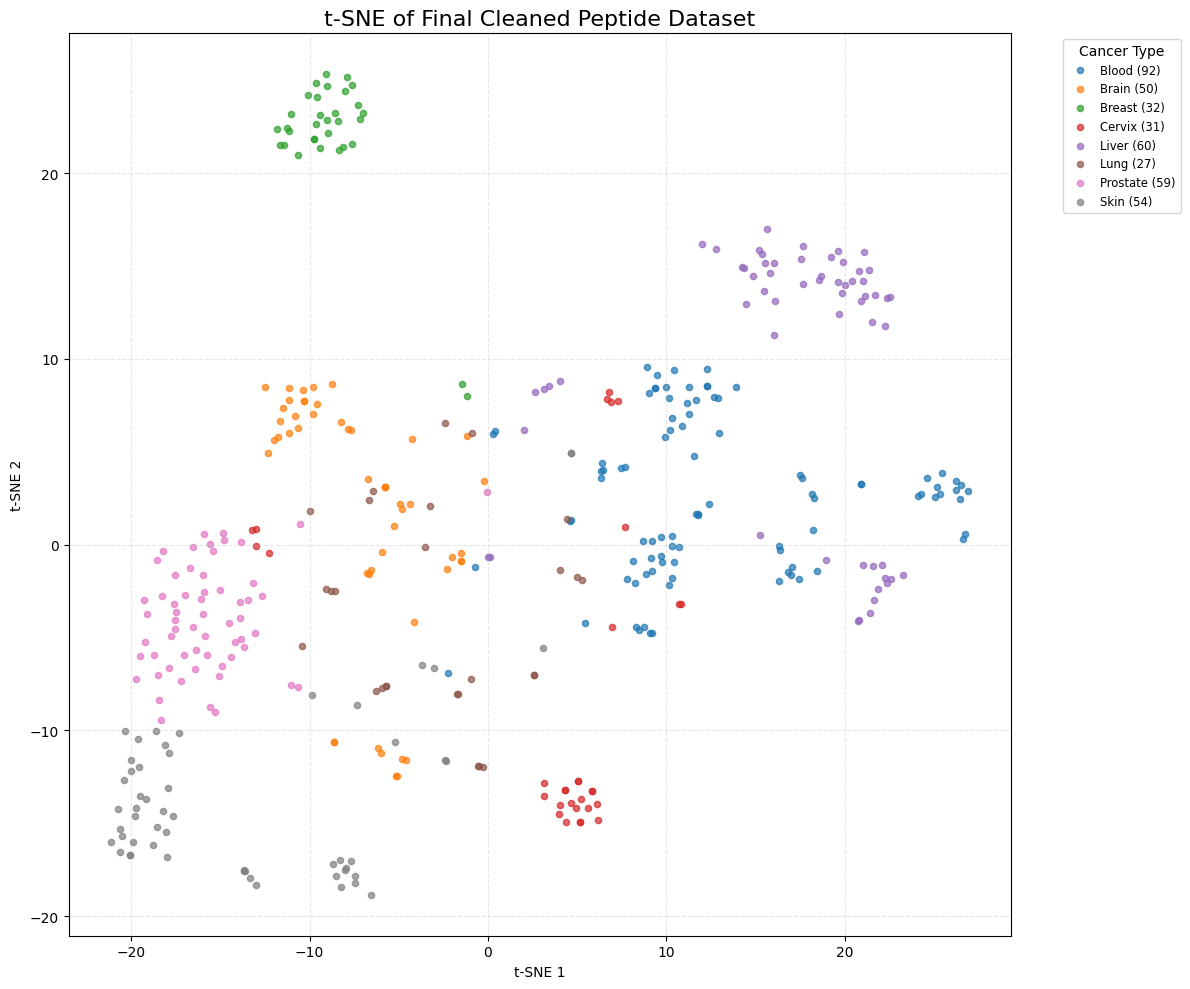

✅ 图像已保存为 tsne_final_data.png


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
from transformers import AutoTokenizer, AutoModel
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ==================== 配置 ====================
INPUT_FILE = "data/processed/prefix_training_data_final.txt"  # 修改为你的实际路径
ESM2_MODEL_PATH = "E:/huggingface/esm2_t6_8M_UR50D"          # 你的ESM2路径
OUTPUT_PLOT = "tsne_final_data.png"
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"使用设备: {DEVICE}")

# ==================== 数据读取 ====================
def read_data(file_path):
    seqs = []
    labels = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            start = line.find('[')
            end = line.find(']')
            if start == -1 or end == -1:
                continue
            label_str = line[start+1:end].strip()
            seq = line[end+1:].strip().upper()
            if not seq or not label_str:
                continue
            # 分割标签（兼容多标签，但你的数据应该是单标签）
            label_list = [l.strip() for l in label_str.split(',') if l.strip()]
            for lab in label_list:
                seqs.append(seq)
                labels.append(lab)
    return seqs, labels

print("📖 读取数据...")
seqs, labels = read_data(INPUT_FILE)
print(f"共找到 {len(seqs)} 条序列")

# 统计标签
counts = Counter(labels)
print("各标签样本数:")
for label, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {label}: {cnt}")

# ==================== ESM2 编码 ====================
def get_esm2_embeddings(sequences, batch_size=32):
    tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_PATH, local_files_only=True)
    model = AutoModel.from_pretrained(ESM2_MODEL_PATH, local_files_only=True).to(DEVICE)
    model.eval()
    
    embeddings = []
    for i in range(0, len(sequences), batch_size):
        batch = sequences[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=50)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        embeddings.append(emb)
    return np.vstack(embeddings)

print("🧬 编码序列...")
embeddings = get_esm2_embeddings(seqs, batch_size=64)
print(f"嵌入矩阵形状: {embeddings.shape}")

# ==================== t-SNE 降维 ====================
print("📉 执行 t-SNE...")
scaler = StandardScaler()
emb_scaled = scaler.fit_transform(embeddings)

n_samples = emb_scaled.shape[0]
# 如果样本过多，先用PCA降维加速
if n_samples > 100:
    n_components = min(50, n_samples-1)
    pca = PCA(n_components=n_components, random_state=42)
    emb_reduced = pca.fit_transform(emb_scaled)
else:
    emb_reduced = emb_scaled

perplexity = min(30, n_samples-1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, init='pca', learning_rate='auto')
emb_tsne = tsne.fit_transform(emb_reduced)

# ==================== 绘图 ====================
unique_labels = sorted(set(labels))
palette = sns.color_palette("tab10", len(unique_labels))
color_map = {label: palette[i] for i, label in enumerate(unique_labels)}

plt.figure(figsize=(12, 10))
for label in unique_labels:
    idx = [i for i, l in enumerate(labels) if l == label]
    x = emb_tsne[idx, 0]
    y = emb_tsne[idx, 1]
    plt.scatter(x, y, c=[color_map[label]], label=f"{label} ({len(idx)})", alpha=0.7, s=20)

plt.title("t-SNE of Final Cleaned Peptide Dataset", fontsize=16)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 图像已保存为 {OUTPUT_PLOT}")

Some weights of EsmModel were not initialized from the model checkpoint at E:/huggingface/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


使用设备: cuda
📖 读取数据...
原始数据: 405 条序列
过滤后剩余 328 条序列
各标签样本数:
  Blood: 92
  Liver: 60
  Prostate: 59
  Skin: 54
  Breast: 32
  Cervix: 31
🧬 编码序列...
嵌入矩阵形状: (328, 320)
📉 执行 t-SNE...


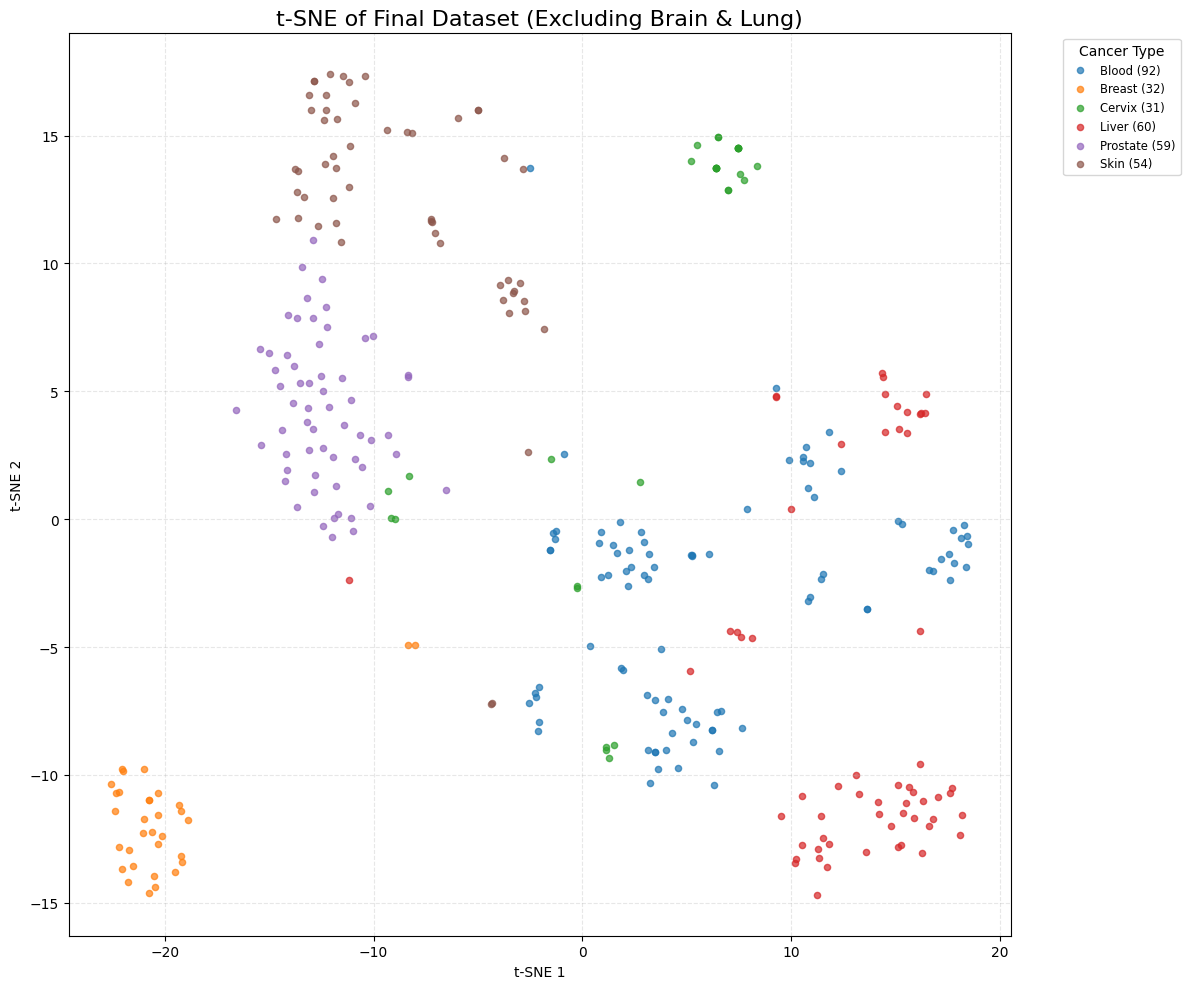

✅ 图像已保存为 tsne_final_data_no_brain_lung.png


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
from transformers import AutoTokenizer, AutoModel
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ==================== 配置 ====================
INPUT_FILE = "data/processed/prefix_training_data_final.txt"  # 修改为你的实际路径
ESM2_MODEL_PATH = "E:/huggingface/esm2_t6_8M_UR50D"          # 你的ESM2路径
OUTPUT_PLOT = "tsne_final_data_no_brain_lung.png"
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"使用设备: {DEVICE}")

# ==================== 数据读取 ====================
def read_data(file_path):
    seqs = []
    labels = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            start = line.find('[')
            end = line.find(']')
            if start == -1 or end == -1:
                continue
            label_str = line[start+1:end].strip()
            seq = line[end+1:].strip().upper()
            if not seq or not label_str:
                continue
            label_list = [l.strip() for l in label_str.split(',') if l.strip()]
            for lab in label_list:
                seqs.append(seq)
                labels.append(lab)
    return seqs, labels

print("📖 读取数据...")
seqs, labels = read_data(INPUT_FILE)
print(f"原始数据: {len(seqs)} 条序列")

# ==================== 过滤掉 Brain 和 Lung ====================
EXCLUDE_LABELS = ['Brain', 'Lung']
filtered_seqs = []
filtered_labels = []
for s, l in zip(seqs, labels):
    if l not in EXCLUDE_LABELS:
        filtered_seqs.append(s)
        filtered_labels.append(l)
seqs, labels = filtered_seqs, filtered_labels
print(f"过滤后剩余 {len(seqs)} 条序列")

# 统计标签分布
counts = Counter(labels)
print("各标签样本数:")
for label, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {label}: {cnt}")

# ==================== ESM2 编码 ====================
def get_esm2_embeddings(sequences, batch_size=32):
    tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_PATH, local_files_only=True)
    model = AutoModel.from_pretrained(ESM2_MODEL_PATH, local_files_only=True).to(DEVICE)
    model.eval()
    
    embeddings = []
    for i in range(0, len(sequences), batch_size):
        batch = sequences[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=50)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        embeddings.append(emb)
    return np.vstack(embeddings)

print("🧬 编码序列...")
embeddings = get_esm2_embeddings(seqs, batch_size=64)
print(f"嵌入矩阵形状: {embeddings.shape}")

# ==================== t-SNE 降维 ====================
print("📉 执行 t-SNE...")
scaler = StandardScaler()
emb_scaled = scaler.fit_transform(embeddings)

n_samples = emb_scaled.shape[0]
if n_samples > 100:
    n_components = min(50, n_samples-1)
    pca = PCA(n_components=n_components, random_state=42)
    emb_reduced = pca.fit_transform(emb_scaled)
else:
    emb_reduced = emb_scaled

perplexity = min(30, n_samples-1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, init='pca', learning_rate='auto')
emb_tsne = tsne.fit_transform(emb_reduced)

# ==================== 绘图 ====================
unique_labels = sorted(set(labels))
palette = sns.color_palette("tab10", len(unique_labels))
color_map = {label: palette[i] for i, label in enumerate(unique_labels)}

plt.figure(figsize=(12, 10))
for label in unique_labels:
    idx = [i for i, l in enumerate(labels) if l == label]
    x = emb_tsne[idx, 0]
    y = emb_tsne[idx, 1]
    plt.scatter(x, y, c=[color_map[label]], label=f"{label} ({len(idx)})", alpha=0.7, s=20)

plt.title("t-SNE of Final Dataset (Excluding Brain & Lung)", fontsize=16)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 图像已保存为 {OUTPUT_PLOT}")